In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# 1. DOWNLOAD DATA
# use 'NVDA' (Nvidia) because it has high volatility, making trends easy to see.

ticker = 'NVDA' 
start_date = '2020-01-01'
end_date = '2025-01-01'

def download_data(ticker, start_date, end_date):
    """Download historical price data for the specified ticker."""
    print(f"Downloading data for {ticker}...")
    try:
        df = yf.download(ticker, start=start_date, end=end_date)
        print(f"Downloaded {len(df)} rows of data for {ticker}")

        # Drop any rows with missing values to prevent errors later
        print(f"Checking for NA values...")
        df = df.dropna()
        print(f"Data filtered. {len(df)} rows of data remaining for {ticker}")



        return df
    except Exception as e:
        print(f"Error downloading data: {e}")
        return None

df = download_data(ticker, start_date, end_date)

# Check if data looks correct (Open, High, Low, Close, Volume)
print(df.head())

[*********************100%***********************]  1 of 1 completed

Downloaded 1258 rows of data for NVDA
Checking for NA values...
Data filtered. 1258 rows of data remaining for NVDA
Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2020-01-02  5.971078  5.971078  5.891683  5.942208  237536000
2020-01-03  5.875505  5.919309  5.826474  5.851363  205384000
2020-01-06  5.900144  5.905371  5.756038  5.782171  262636000
2020-01-07  5.971577  6.017372  5.883470  5.928519  314856000
2020-01-08  5.982777  6.024092  5.927275  5.967345  277108000


In [11]:
# 2. IMPLEMENT STRATEGY
# Calculate Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Create Signals (1 = Buy, 0 = Sell/Cash)
df['Signal'] = np.where(df['SMA_20'] > df['SMA_50'], 1.0, 0.0)

# CRITICAL STEP: Create 'Position'
# For this one, we will do an experiment with no shifting
# It will create a "Look-ahead Bias" (cheating); hence, we expect a better return here.
df['Position'] = df['Signal']

print("Strategy indicators created.")
df.to_csv("strategy_no_shift.csv")
print(df.tail(5))

Strategy indicators created.
Price            Close        High         Low        Open     Volume  \
Ticker            NVDA        NVDA        NVDA        NVDA       NVDA   
Date                                                                    
2024-12-24  140.181656  141.861189  138.612078  139.961715  105157000   
2024-12-26  139.891724  140.811485  137.692328  139.661791  116205600   
2024-12-27  136.972534  138.981994  134.673175  138.512122  170582600   
2024-12-30  137.452393  140.231631  133.983341  134.793117  167734700   
2024-12-31  134.253281  138.032261  133.793415  137.992264  155659200   

Price           SMA_20      SMA_50 Signal Position  
Ticker                                              
Date                                                
2024-12-24  137.129113  139.715785    0.0      0.0  
2024-12-26  137.280043  139.882520    0.0      0.0  
2024-12-27  137.363987  139.908500    0.0      0.0  
2024-12-30  137.326472  139.919885    0.0      0.0  
2024-12-31  137

In [12]:
# 3. CALCULATE RETURNS
# Calculate daily percent change of the stock
df['Market_Return'] = df['Close'].pct_change()

# Calculate Strategy Returns
# If Position was 1 yesterday, we get the Market_Return today.
# If Position was 0, we get 0 return.
df['Strategy_Return'] = df['Position'] * df['Market_Return']

# 4. CALCULATE METRICS
# Cumulative Returns (for plotting)
df['Cumulative_Market_Return'] = (1 + df['Market_Return']).cumprod()
df['Cumulative_Strategy_Return'] = (1 + df['Strategy_Return']).cumprod()

# Sharpe Ratio (Risk-Adjusted Return)
# Assuming 252 trading days in a year. 
# A Sharpe > 1 is generally considered "good" for a basic strategy.
sharpe_ratio = (df['Strategy_Return'].mean() / df['Strategy_Return'].std()) * np.sqrt(252)

# Max Drawdown (Worst loss from a peak)
# Calculate running maximum
running_max = df['Cumulative_Strategy_Return'].cummax()
drawdown = (df['Cumulative_Strategy_Return'] / running_max) - 1
max_drawdown = drawdown.min()

print(f"--- Performance Metrics for {ticker} ---")
print(f"Total Market Return: {df['Cumulative_Market_Return'].iloc[-1]:.2f}x")
print(f"Total Strategy Return: {df['Cumulative_Strategy_Return'].iloc[-1]:.2f}x")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")

--- Performance Metrics for NVDA ---
Total Market Return: 22.48x
Total Strategy Return: 8.78x
Sharpe Ratio: 1.23
Max Drawdown: -54.41%


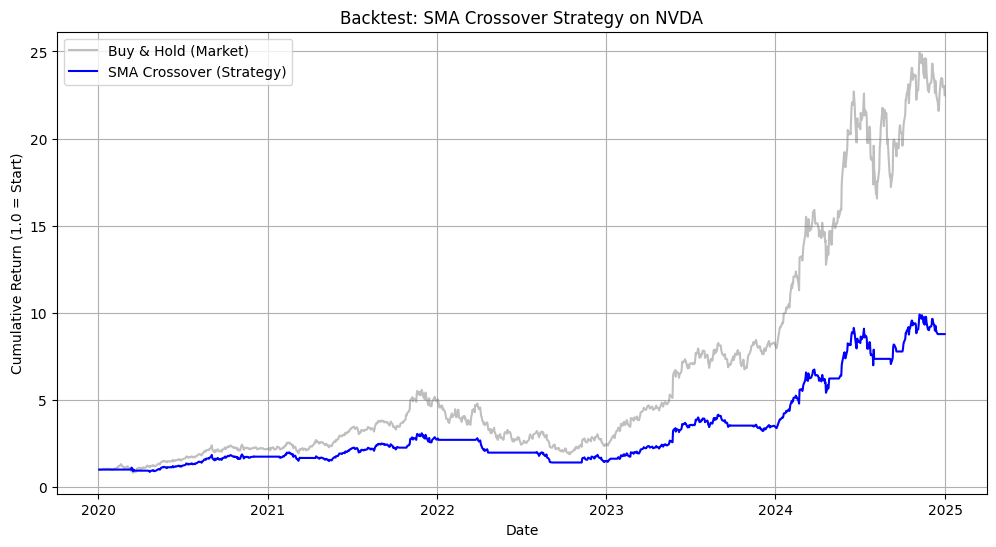

In [13]:
# 5. VISUALIZE
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cumulative_Market_Return'], label='Buy & Hold (Market)', color='gray', alpha=0.5)
plt.plot(df.index, df['Cumulative_Strategy_Return'], label='SMA Crossover (Strategy)', color='blue')

plt.title(f'Backtest: SMA Crossover Strategy on {ticker}')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (1.0 = Start)')
plt.legend()
plt.grid(True)
plt.show()